In [2]:
import os
# Project structure
PROJECT_ROOT = os.path.dirname(os.getcwd())

FACE_DETECTION_PATH = os.path.join(PROJECT_ROOT, 'models', 'face_detection_new')
FACE_DETECTION_MODEL = os.path.join(FACE_DETECTION_PATH, 'runs', 'face_yolo11s', 'weights', 'best.pt')
                                    
FACE_RECOGNITION_PATH = os.path.join(PROJECT_ROOT, 'models', 'face_recognition')
FACE_RECOGNITION_MODEL = os.path.join(FACE_RECOGNITION_PATH, 'arcface2.onnx')

In [3]:
import torch
import cv2
from ultralytics import YOLO
import numpy as np
import onnxruntime as ort
import matplotlib.pyplot as plt

In [4]:
# --- Load YOLO Face Detector (.pt) ---
model = YOLO(FACE_DETECTION_MODEL)
model.conf = 0.40  # confidence threshold

In [5]:
# --- Load ArcFace ONNX ---
session = ort.InferenceSession(FACE_RECOGNITION_MODEL, providers=["CPUExecutionProvider"])

In [6]:
inp = session.get_inputs()[0]
inp_name = inp.name
print(inp.name, inp.shape, inp.type)

input [1, 3, 160, 160] tensor(float)


In [7]:
# ArcFace preprocess (NCHW)
def preprocess(path=None, img=None):
    if path is not None:
        img = cv2.imread(path)
        if img is None:
            raise ValueError(f"Image not found: {path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    elif img is None:
        raise ValueError("No image provided to preprocess()")

    if img.size == 0:
        raise ValueError("Empty image passed to preprocess()")

    img = cv2.resize(img, (160, 160))

    img = img.astype(np.float32)
    img = (img - 127.5) / 128.0        # ArcFace normalization

    img = img.transpose(2, 0, 1)       # HWC → CHW
    img = np.expand_dims(img, 0)       # (1,3,112,112)

    return img



def cosine_similarity(a, b):
    a = a / np.linalg.norm(a)
    b = b / np.linalg.norm(b)
    return float(np.dot(a, b))

In [8]:
def detect_and_visualize(image_path):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Image not found: {image_path}")
    
    results = model(img)
    result = results[0]

    # Extract bounding boxes
    boxes = result.boxes
    if boxes is None or len(boxes) == 0:
        print("No faces detected.")
        return img, np.zeros((0,4))

    detections = boxes.xyxy.cpu().numpy().astype(int)   # <--- FIXED (int coords)
    confs      = boxes.conf.cpu().numpy()
    clss       = boxes.cls.cpu().numpy()

    # Draw boxes
    for (x1, y1, x2, y2), conf in zip(detections, confs):
        cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)
        cv2.putText(img, f"{conf:.2f}", (x1, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

    # Show image
    plt.figure(figsize=(8,8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    return img, detections


In [9]:
def get_embeddings_from_detection(img, detections):
    embeddings = []
    crops = []

    for x1, y1, x2, y2 in detections:
        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
        face = img[y1:y2, x1:x2]
        if face.size == 0:
            print("EMPTY FACE CROP → skip")
            continue

        rgb = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
        
        processed = preprocess(img=rgb)
        
        # ADD THIS
        print("FACE CROP SHAPE:", face.shape)
        print("RGB SHAPE:", rgb.shape)
        print("PROCESSED SHAPE:", processed.shape)
        print("PROCESSED MIN/MAX:", processed.min(), processed.max())
        print("----------------------------")

        emb = session.run(None, {inp_name: processed})[0].flatten()
        embeddings.append(emb)
        crops.append(rgb)

    return embeddings, crops


In [10]:
def full_pipeline(image_path):
    print("Detecting faces…")
    img, det = detect_and_visualize(image_path)

    print(f"Detected {len(det)} faces.")

    embeddings, crops = get_embeddings_from_detection(img, det)

    # visualize crops
    for i, crop in enumerate(crops):
        plt.figure(figsize=(3,3))
        plt.imshow(crop)
        plt.title(f"Face {i+1}")
        plt.axis("off")

    return embeddings, crops

In [11]:
def compare_faces(emb1, emb2):
    sim = cosine_similarity(emb1, emb2)
    print("Cosine Similarity:", sim)
    return sim

Detecting faces…

0: 640x448 1 face, 4137.5ms
Speed: 508.9ms preprocess, 4137.5ms inference, 284.5ms postprocess per image at shape (1, 3, 640, 448)
Detected 1 faces.
FACE CROP SHAPE: (653, 459, 3)
RGB SHAPE: (653, 459, 3)
PROCESSED SHAPE: (1, 3, 160, 160)
PROCESSED MIN/MAX: -0.99609375 0.99609375
----------------------------
Detecting faces…

0: 640x384 1 face, 1952.9ms
Speed: 16.3ms preprocess, 1952.9ms inference, 7.1ms postprocess per image at shape (1, 3, 640, 384)
Detected 1 faces.
FACE CROP SHAPE: (1682, 1071, 3)
RGB SHAPE: (1682, 1071, 3)
PROCESSED SHAPE: (1, 3, 160, 160)
PROCESSED MIN/MAX: -0.99609375 0.99609375
----------------------------
Cosine Similarity: 0.7684470415115356


0.7684470415115356

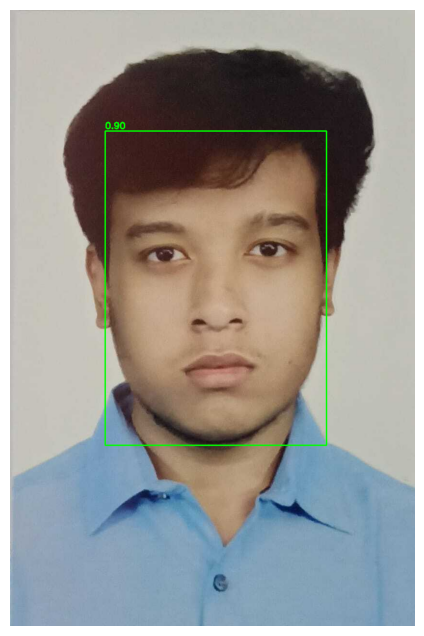

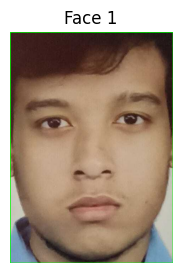

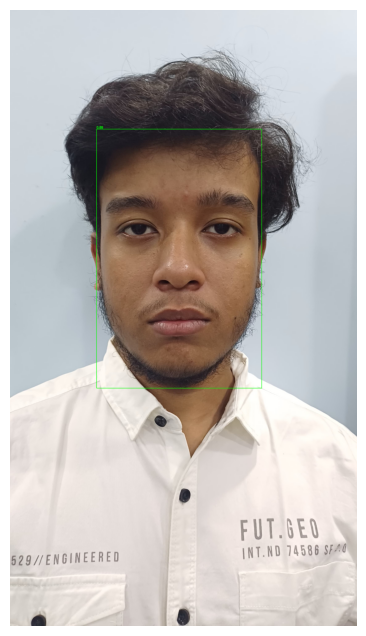

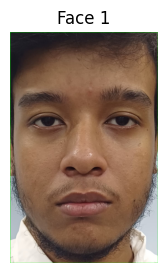

In [12]:
embs1, _ = full_pipeline("ayush1.jpg")
embs2, _ = full_pipeline("ayush2.jpg")

compare_faces(embs1[0], embs2[0])

Detecting faces…

0: 640x448 1 face, 10581.1ms
Speed: 66.4ms preprocess, 10581.1ms inference, 22.3ms postprocess per image at shape (1, 3, 640, 448)
Detected 1 faces.
FACE CROP SHAPE: (653, 459, 3)
RGB SHAPE: (653, 459, 3)
PROCESSED SHAPE: (1, 3, 160, 160)
PROCESSED MIN/MAX: -0.99609375 0.99609375
----------------------------
Detecting faces…

0: 640x640 1 face, 5636.1ms
Speed: 110.3ms preprocess, 5636.1ms inference, 14.1ms postprocess per image at shape (1, 3, 640, 640)
Detected 1 faces.
FACE CROP SHAPE: (178, 120, 3)
RGB SHAPE: (178, 120, 3)
PROCESSED SHAPE: (1, 3, 160, 160)
PROCESSED MIN/MAX: -0.99609375 0.99609375
----------------------------
Cosine Similarity: 0.1794426441192627


0.1794426441192627

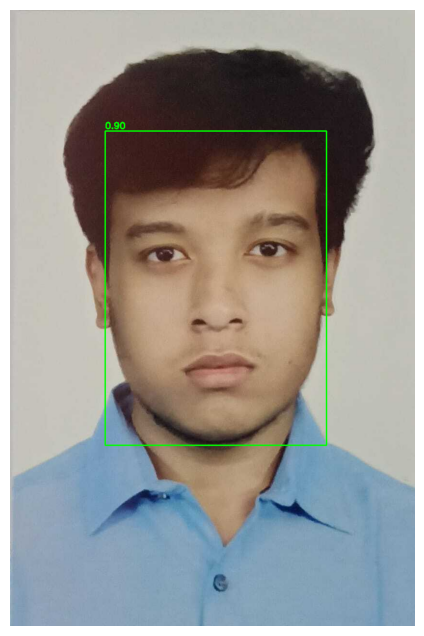

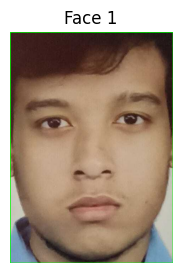

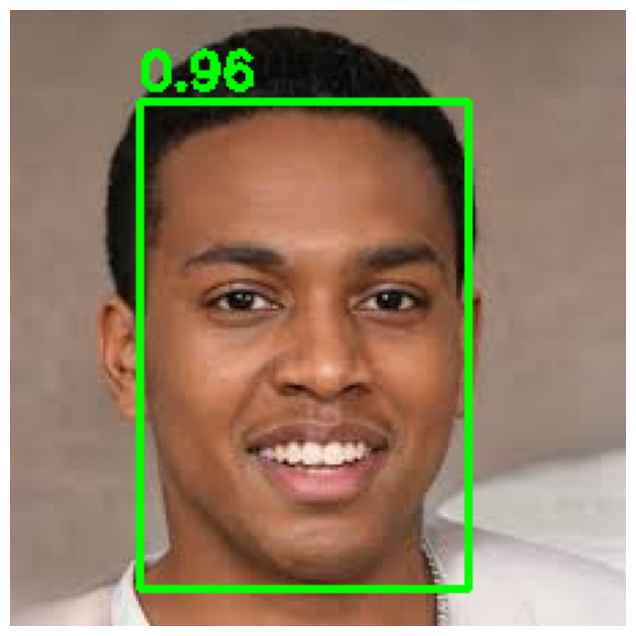

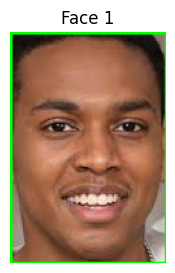

In [13]:
embs1, _ = full_pipeline("ayush1.jpg")
embs2, _ = full_pipeline("random_other.jpg")

compare_faces(embs1[0], embs2[0])